In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np

data_path = "/content/drive/MyDrive/NIDS/NIDS_processed_data"

X_train = np.load(f"{data_path}/X_train_final.npy")
X_test = np.load(f"{data_path}/X_test_final.npy")

y_train = np.load(f"{data_path}/y_train_encoded.npy")
y_test = np.load(f"{data_path}/y_test_encoded.npy")

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training data: (1785444, 55)
Testing data: (446362, 55)
Training target: (1785444,)
Testing target: (446362,)


In [3]:
print("NaN values in X_train:", np.isnan(X_train).sum())
print("NaN values in X_test :", np.isnan(X_test).sum())

print("Infinite values in X_train:", np.isinf(X_train).sum())
print("Infinite values in X_test :", np.isinf(X_test).sum())

NaN values in X_train: 0
NaN values in X_test : 0
Infinite values in X_train: 0
Infinite values in X_test : 0


In [4]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=15,
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

print("XGBoost model created.")

XGBoost model created.


In [5]:
import time

print("Starting XGBoost training...")

start_time = time.time()

xgb_model.fit(X_train, y_train)

training_time = time.time() - start_time

print("Training completed.")
print(f"Training time: {training_time:.2f} seconds")
print(f"Training time: {training_time / 60:.2f} minutes")

Starting XGBoost training...
Training completed.
Training time: 696.72 seconds
Training time: 11.61 minutes


In [6]:
print("Making predictions...")

y_pred_xgb = xgb_model.predict(X_test)

print("Predictions completed.")
print("Prediction shape:", y_pred_xgb.shape)

Making predictions...
Predictions completed.
Prediction shape: (446362,)


In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_xgb)
macro_precision = precision_score(y_test, y_pred_xgb, average="macro", zero_division=0)
macro_recall = recall_score(y_test, y_pred_xgb, average="macro", zero_division=0)
macro_f1 = f1_score(y_test, y_pred_xgb, average="macro", zero_division=0)
weighted_f1 = f1_score(y_test, y_pred_xgb, average="weighted", zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

Accuracy: 0.9989
Macro Precision: 0.9320
Macro Recall: 0.8370
Macro F1: 0.8704
Weighted F1: 0.9989

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    379064
           1       0.90      0.65      0.75       288
           2       1.00      1.00      1.00     25603
           3       1.00      1.00      1.00      2057
           4       1.00      1.00      1.00     34569
           5       0.95      0.99      0.97      1046
           6       1.00      1.00      1.00      1077
           7       1.00      1.00      1.00      1186
           8       1.00      0.50      0.67         2
           9       1.00      0.86      0.92         7
          10       0.94      0.93      0.94       391
          11       1.00      1.00      1.00       644
          12       0.73      0.83      0.78       294
          13       1.00      0.50      0.67         4
          14       0.47      0.32      0.38       130

    accurac

In [9]:
import joblib

label_encoder = joblib.load("/content/drive/MyDrive/NIDS/NIDS_processed_data/label_encoder.pkl")

print("Label encoder loaded.")
print("Classes:", label_encoder.classes_)

Label encoder loaded.
Classes: ['Benign' 'Bot' 'DDoS' 'DoS GoldenEye' 'DoS Hulk' 'DoS Slowhttptest'
 'DoS slowloris' 'FTP-Patator' 'Heartbleed' 'Infiltration' 'PortScan'
 'SSH-Patator' 'Web Attack � Brute Force' 'Web Attack � Sql Injection'
 'Web Attack � XSS']


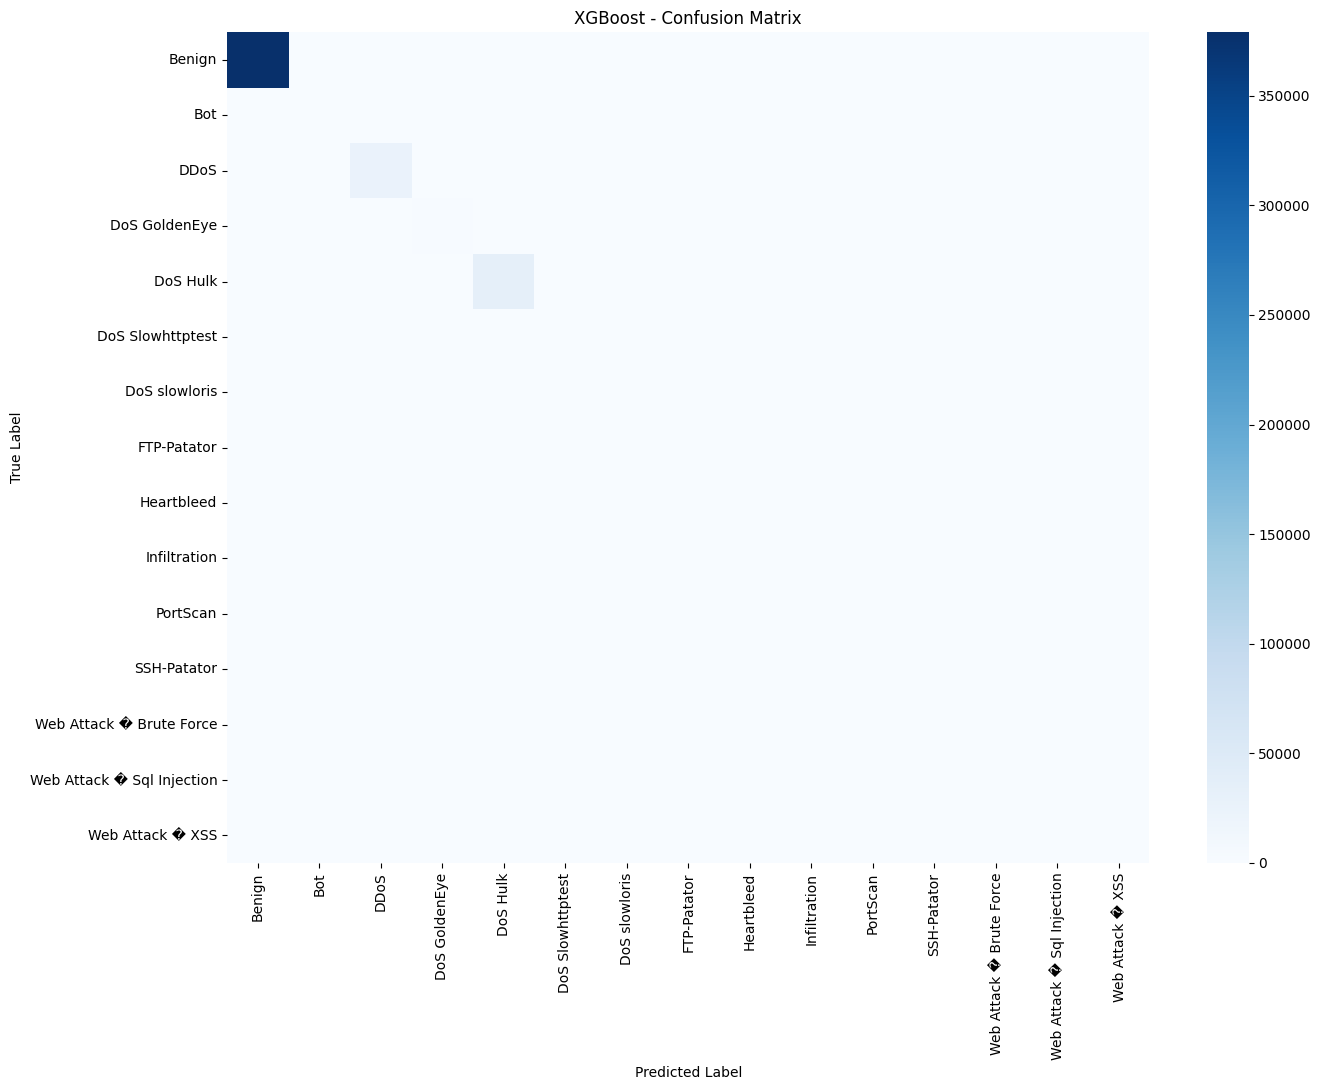

In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(14, 11))

sns.heatmap(
    cm_xgb,
    annot=False,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("XGBoost - Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [12]:
import os
import joblib
import json

os.makedirs("/content/drive/MyDrive/NIDS/models", exist_ok=True)
os.makedirs("/content/drive/MyDrive/NIDS/results", exist_ok=True)

# Save trained XGBoost model
joblib.dump(
    xgb_model,
    "/content/drive/MyDrive/NIDS/models/xgboost.pkl"
)

# Save evaluation metrics
xgb_results = {
    "model": "XGBoost",
    "accuracy": accuracy,
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
    "training_time_seconds": training_time
}

with open(
    "/content/drive/MyDrive/NIDS/results/xgboost_metrics.json",
    "w"
) as f:
    json.dump(xgb_results, f, indent=4)

print("XGBoost model saved.")
print("XGBoost metrics saved.")

XGBoost model saved.
XGBoost metrics saved.
